# BEAD Random Forest — Final Model
Log-transformed target with 6 features (post-ablation).

Dropped after ablation (zero or negative contribution): `avg_latency`, `priority_broadband_project`, `incumbent_democrat`

Includes SHAP and LIME interpretability analysis.

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

Connected to BigQuery: broadband-data


In [ ]:
# Load all data sources
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs, project_type, priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT *
FROM `broadband-data.fp_approved.project_loc_counts`
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}

print(f'''Projects: {df_projects.shape},
Locations: {df_locations.shape}
''')

Projects: (5740, 8),
Locations: (5738, 5)



In [ ]:
df_technology = client.query("""
SELECT *
FROM `broadband-data.fp_approved.loc_proj_subgrantee`
""")

In [5]:
df_technology.provider_id.isna().value_counts()

provider_id
False    3131801
True      636874
Name: count, dtype: int64

In [6]:
df_incumbency = client.query("""
    WITH loc_block_lookup AS (
      SELECT
        location_id,
        block_geoid,
        ROW_NUMBER() OVER (
          PARTITION BY location_id
          ORDER BY period DESC
        ) AS rn
      FROM (
        SELECT DISTINCT location_id, block_geoid, period
        FROM `broadband-data.fcc_bdc.nbm_hive`
        WHERE location_id IN (
          SELECT location_id FROM `broadband-data.fp_approved.loc_proj_subgrantee`
        )
      )
    ),

    resolved_locs AS (
      SELECT location_id, block_geoid
      FROM loc_block_lookup
      WHERE rn = 1
    ),

    block_level_total AS (
      SELECT block_geoid, COUNT(DISTINCT location_id) AS n_locations
      FROM `broadband-data.fcc_bdc.nbm_hive`
      WHERE period = '2024_12'
      GROUP BY block_geoid
    ),

    block_level_isp_count AS (
      SELECT block_geoid, provider_id, COUNT(DISTINCT location_id) AS provider_count
      FROM `broadband-data.fcc_bdc.nbm_hive`
      WHERE period = '2024_12'
      GROUP BY block_geoid, provider_id
    )

    SELECT
        s.location_id,
        s.project_id,
        s.state,
        s.provider_id,
        r.block_geoid,
        blt.n_locations AS n_locs,
        COALESCE(b.provider_count, 0) AS present_locations,
        100.0 * COALESCE(b.provider_count, 0) / blt.n_locations AS prov_coverage
    FROM `broadband-data.fp_approved.loc_proj_subgrantee` s
    JOIN resolved_locs r USING (location_id)
    JOIN block_level_total blt USING (block_geoid)
    LEFT JOIN block_level_isp_count b
        ON b.block_geoid = r.block_geoid
        AND b.provider_id = s.provider_id
""").to_dataframe()

In [7]:
print(f"{df_technology.shape}, {df_incumbency.shape}")

(3768675, 11), (3763474, 8)


In [8]:
df_competition = df_incumbency.merge(df_technology,
    on = ['location_id', 'provider_id', 'state', 'project_id'],
    how = 'right')

In [9]:
proj_comp = df_competition.groupby('project_id').agg(
    state = ('state', 'first'),
    prov_coverage = ('prov_coverage', 'mean'),
    provider_id = ('provider_id', 'first'),
    frn = ('frn', 'first'),
    n_blocks = ('block_geoid', 'nunique'),
    n_locs = ('location_id', 'count')
).reset_index()

In [36]:
# Merge + feature engineering
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(proj_comp, on='project_id', how='left')
df = df.merge(tech_shares, on='project_id', how='left')
df = df.merge(df_bead_proj, on='project_id', how='left')
# df = df.merge(df_nbm, on='state', how='left')
# df = df.merge(df_state_pop, on='state', how='left')

df['funded_locations'] = df['n_locs'].fillna(0)
# df['technology'] = df['technology'].fillna(0)
# df['state_num_providers'] = df['state_num_providers'].fillna(0)
# df['state_population'] = df['state_population'].fillna(0)

df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)
df['has_incumbent'] = (df['prov_coverage'] > 0).astype(int)

df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df['cai_ratio'] = df['n_cai_only'] /  df['n_total']
df = df.dropna(subset=['funding_per_location'])
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

df['log_funding'] = np.log1p(df['funding_per_location'])
print(f'Samples: {df.shape[0]}')

Samples: 5446


In [264]:
from sklearn.preprocessing import OrdinalEncoder

state_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
state_encoded = state_enc.fit_transform(df[['state_x']])
df['state_encoded'] = state_encoded

In [84]:
# Final model: 6 features, log target
feature_cols = [
    'miles_per_location',    # Ablation R² drop: +0.039
    #'technology',            # Ablation R² drop: +0.039
    'jobs_per_location',     # Ablation R² drop: +0.020
    #'state_population',      # Ablation R² drop: +0.010
    'total_fiber_miles',     # Ablation R² drop: +0.006
    #'state_num_providers',   # Ablation R² drop: +0.001
    #'state_encoded',
    'has_incumbent',
    'frac_tech_40',
    'frac_tech_50',
    'frac_tech_61',
    'frac_tech_71',
    'cai_ratio',
    'n_total',
    'present_at_location'
]

X = df[feature_cols].fillna(0)
y = df['log_funding']
groups = df['state_x']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print('=== Final Model: 6 Features, log(funding_per_location) ===')
print(f'Test R² (log):   {r2:.4f}')
print(f'CV R² (log):     {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'RMSE (real $):   {rmse:,.0f}')
print(f'MAE (real $):    {mae:,.0f}')

=== Final Model: 6 Features, log(funding_per_location) ===
Test R² (log):   0.6290
CV R² (log):     0.6401 +/- 0.0177
RMSE (real $):   3,719
MAE (real $):    2,156


In [19]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(rf, X, y, cv=kf, groups=groups, scoring='r2', return_estimator=False)
print(cv_results['test_score'])  # see the actual 5 numbers, not just mean±sd

[0.61135604 0.64496859 0.63741628 0.63990308 0.66687227]


In [20]:
from sklearn.model_selection import cross_val_predict

y_pred_oof = cross_val_predict(rf, X, y, cv=kf, groups=groups, n_jobs=-1)
r2_pooled = r2_score(y, y_pred_oof)
print(f'Pooled out-of-fold R²: {r2_pooled:.4f}')

Pooled out-of-fold R²: 0.6402


In [21]:
footprint_cols = ['miles_per_location', 'jobs_per_location', 'total_fiber_miles']
X_fp = df[footprint_cols].fillna(0)

rf_fp = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
cv_r2_fp = cross_val_score(rf_fp, X_fp, y, cv=kf, groups=groups, scoring='r2', n_jobs=-1)
print(cv_r2_fp)
print(cv_r2_fp.mean(), cv_r2_fp.std())

[0.42130467 0.40385185 0.42064204 0.37466821 0.41620714]
0.4073347822118822 0.017493971740131738


In [306]:
y_pred_oof_fp = cross_val_predict(rf_fp, X_fp, y, cv=kf, groups=groups, n_jobs=-1)
r2_pooled_fp = r2_score(y, y_pred_oof_fp)

y_pred_oof_full = cross_val_predict(rf, X, y, cv=kf, groups=groups, n_jobs=-1)
r2_pooled_full = r2_score(y, y_pred_oof_full)

print(f'Footprint-only pooled R²: {r2_pooled_fp:.4f}')
print(f'Full-feature pooled R²:   {r2_pooled_full:.4f}')

Footprint-only pooled R²: 0.2595
Full-feature pooled R²:   0.2354


In [65]:
test = df.groupby('state_x').agg( 
    {
    'miles_per_location': list,
    'total_fiber_miles': list,
    'prov_coverage': list
    }   
).reset_index()

In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GroupShuffleSplit, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Final model: 6 features, log target
feature_cols = [
    'miles_per_location',    # Ablation R² drop: +0.039
    #'technology',            # Ablation R² drop: +0.039
    'jobs_per_location',     # Ablation R² drop: +0.020
    #'state_population',      # Ablation R² drop: +0.010
    # 'total_fiber_miles',     # Ablation R² drop: +0.006
    #'state_num_providers',   # Ablation R² drop: +0.001
    #'state_encoded',
    #'has_incumbent',
    'prov_coverage',
    'frac_tech_40',
    'frac_tech_50',
    'frac_tech_61',
    'frac_tech_71',
    'present_at_location',
    'cai_ratio',
    'n_total',
    #'n_cai_only'
]

X = df[feature_cols].fillna(0)
y = df['log_funding']
groups = df['state_x']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
kf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(
    rf, X, y, cv=kf, groups=groups, scoring='r2', n_jobs=-1,
)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print('=== Final Model: 6 Features, log(funding_per_location) ===')
print(f'Test R² (log):   {r2:.4f}')
print(f'CV R² (log):     {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'RMSE (real $):   {rmse:,.0f}')
print(f'MAE (real $):    {mae:,.0f}')

=== Final Model: 6 Features, log(funding_per_location) ===
Test R² (log):   0.4102
CV R² (log):     0.3529 +/- 0.2641
RMSE (real $):   5,409
MAE (real $):    3,351


In [378]:
df_tech_cleaned = df_technology[['state','location_id','frn','provider_id']]

In [380]:
df_tech_cleaned.to_csv('../fp.csv')

In [342]:
gss.get_n_splits()

5

In [343]:
for i, (train_idx, test_idx) in enumerate(kf.split(X_fp, y, groups=groups)):
    test_states = sorted(groups.iloc[test_idx].unique())
    n_test = len(test_idx)
    print(f"Fold {i}: n_test={n_test}, states={test_states}")

Fold 0: n_test=641, states=['ID', 'KY', 'MA', 'MS', 'MT', 'NJ', 'NV', 'SC', 'VT', 'WV']
Fold 1: n_test=2155, states=['AZ', 'CA', 'CT', 'DE', 'IA', 'IN', 'PA', 'TN', 'WA', 'WI']
Fold 2: n_test=648, states=['AK', 'CO', 'FL', 'KS', 'MO', 'ND', 'NM', 'NY', 'OH', 'VA']
Fold 3: n_test=852, states=['AL', 'AR', 'HI', 'ME', 'MN', 'NH', 'OK', 'OR', 'SD', 'UT']
Fold 4: n_test=1150, states=['DC', 'GA', 'IL', 'LA', 'MD', 'MI', 'NE', 'RI', 'TX', 'WY']


In [324]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(rf, X, y, cv=kf, groups=groups, scoring='r2', return_estimator=False)
print(cv_results['test_score'])  # see the actual 5 numbers, not just mean±sd

[ 0.29687193 -0.21741106  0.34679649  0.50244177  0.49687768]


In [ ]:
import numpy as np
from sklearn.model_selection import PredefinedSplit, cross_val_score

def balanced_group_folds(groups, n_splits=5, random_state=42):
    sizes = groups.value_counts()
    rng = np.random.RandomState(random_state)
    order = sizes.sample(frac=1, random_state=rng).index  # shuffle ties
    order = sizes.loc[order].sort_values(ascending=False).index.tolist()
    fold_totals = [0] * n_splits
    assignment = {}
    for g in order:
        f = int(np.argmin(fold_totals))
        assignment[g] = f
        fold_totals[f] += sizes[g]
    return groups.map(assignment).values

groups = df['state_x']
test_fold = balanced_group_folds(groups, n_splits=5)
ps = PredefinedSplit(test_fold=test_fold)
cv_r2_balanced = cross_val_score(rf, X, y, cv=ps, scoring='r2', n_jobs=-1)

In [349]:
for i, fold in enumerate(np.unique(test_fold)):
    mask = test_fold == fold
    print(f"Fold {i}: n_test={mask.sum()}, states={sorted(groups[mask].unique())}")

Fold 0: n_test=1091, states=['HI', 'IN', 'OH', 'VT']
Fold 1: n_test=1086, states=['CO', 'CT', 'FL', 'LA', 'MI', 'ND', 'NE', 'NM', 'NY', 'SD', 'VA', 'WA']
Fold 2: n_test=1086, states=['AK', 'AL', 'AZ', 'CA', 'DC', 'DE', 'IA', 'ME', 'MN', 'MS', 'NV', 'OR']
Fold 3: n_test=1092, states=['AR', 'ID', 'KY', 'MD', 'MO', 'MT', 'NJ', 'SC', 'TN', 'TX', 'WY']
Fold 4: n_test=1091, states=['GA', 'IL', 'KS', 'MA', 'NH', 'OK', 'PA', 'RI', 'UT', 'WI', 'WV']


In [125]:
# from sklearn.model_selection import cross_val_predict

# y_pred_oof = cross_val_predict(rf, X, y, cv=ps, n_jobs=-1)  # or your GroupKFold
# pooled_r2 = r2_score(y, y_pred_oof)
# print(f"Pooled OOF R²: {pooled_r2:.4f}")

# # per-state breakdown, same predictions
# resid_df = pd.DataFrame({'state': groups, 'y': y, 'y_pred': y_pred_oof})
# state_r2 = resid_df.groupby('state').apply(
#     lambda g: r2_score(g['y'], g['y_pred']) if len(g) > 5 else np.nan
# ).sort_values()

In [ ]:
# Final model: 6 features, log target
feature_cols = [
    'miles_per_location',    # Ablation R² drop: +0.039
    #'technology',            # Ablation R² drop: +0.039
    'jobs_per_location',     # Ablation R² drop: +0.020
    #'state_population',      # Ablation R² drop: +0.010
    'total_fiber_miles',     # Ablation R² drop: +0.006
    #'state_num_providers',   # Ablation R² drop: +0.001
    #'state_encoded',
    'has_incumbent',
    'frac_tech_40',
    'frac_tech_50',
    'frac_tech_61',
    'frac_tech_71',
    'n_total',
    'present_at_location'
]

for state, abbr in state_name_to_abbr.items():
    state_df = df[df['technology'] == abbr]
    X = state_df[feature_cols].fillna(0)
    y = state_df['log_funding']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

    print(f'=== Final Model for {abbr}')
    print(f'Test R² (log):   {r2:.4f}')
    print(f'CV R² (log):     {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
    print(f'RMSE (real $):   {rmse:,.0f}')
    print(f'MAE (real $):    {mae:,.0f}')

=== Final Model for AL
Test R² (log):   0.7413
CV R² (log):     0.5540 +/- 0.0895
RMSE (real $):   2,144
MAE (real $):    1,467


In [351]:
in_mask = groups == 'IN'
rf.fit(X[~in_mask], y[~in_mask])
y_pred_in = rf.predict(X[in_mask])
print(f"Indiana-only R²: {r2_score(y[in_mask], y_pred_in):.4f}")
print(f"Mean residual (over/under-predict): {(y[in_mask] - y_pred_in).mean():.3f}")

Indiana-only R²: -0.0828
Mean residual (over/under-predict): -0.124


In [365]:
outlier_states = ['CA', 
        'AK', 
        'ME',
        'AZ',
        'IN',
        'FL',
        'LA',
        'MT',
        'RI',
        'OH',
        'UT',
        'KS',
        'ID'
]
mask = ~groups.isin(outlier_states)
trimmed_r2 = r2_score(y[mask], y_pred_oof[mask])
print(f"Pooled OOF R² excluding outlier states: {trimmed_r2:.4f}")

Pooled OOF R² excluding outlier states: 0.6245


In [ ]:
# Predicted vs Actual + Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Log scale
axes[0].scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual log(Funding/Location)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Log Scale | R²={r2:.3f}')

# Real $ scale
yt_real = np.expm1(y_test)
yp_real = np.expm1(y_pred)
axes[1].scatter(yt_real, yp_real, alpha=0.4, s=20, color='steelblue')
lims2 = [min(yt_real.min(), yp_real.min()), max(yt_real.max(), yp_real.max())]
axes[1].plot(lims2, lims2, 'r--')
axes[1].set_xlabel('Actual Funding/Location ($)')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Real $ Scale')

# Feature importance
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
imp.plot.barh(ax=axes[2], color='steelblue')
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importances')

plt.tight_layout()
plt.show()

# Final Model

## Combining new features

### Project-level features


In [6]:
# Load all data sources
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs, project_type, priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT *
FROM `broadband-data.fp_approved.project_loc_counts`
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}

In [7]:
df_technology = client.query("""
SELECT *
FROM `broadband-data.fp_approved.loc_proj_subgrantee`
""").to_dataframe()

In [8]:
df_incumbency = client.query("""
    WITH loc_block_lookup AS (
      SELECT
        location_id,
        block_geoid,
        ROW_NUMBER() OVER (
          PARTITION BY location_id
          ORDER BY period DESC
        ) AS rn
      FROM (
        SELECT DISTINCT location_id, block_geoid, period
        FROM `broadband-data.fcc_bdc.nbm_hive`
        WHERE location_id IN (
          SELECT location_id FROM `broadband-data.fp_approved.loc_proj_subgrantee`
        )
      )
    ),

    resolved_locs AS (
      SELECT location_id, block_geoid
      FROM loc_block_lookup
      WHERE rn = 1
    ),

    block_level_total AS (
      SELECT block_geoid, COUNT(DISTINCT location_id) AS n_locations
      FROM `broadband-data.fcc_bdc.nbm_hive`
      WHERE period = '2024_12'
      GROUP BY block_geoid
    ),

    block_level_isp_count AS (
      SELECT block_geoid, provider_id, COUNT(DISTINCT location_id) AS provider_count
      FROM `broadband-data.fcc_bdc.nbm_hive`
      WHERE period = '2024_12'
      GROUP BY block_geoid, provider_id
    )

    SELECT
        s.location_id,
        s.project_id,
        s.state,
        s.provider_id,
        r.block_geoid,
        blt.n_locations AS n_locs,
        COALESCE(b.provider_count, 0) AS present_locations,
        100.0 * COALESCE(b.provider_count, 0) / blt.n_locations AS prov_coverage
    FROM `broadband-data.fp_approved.loc_proj_subgrantee` s
    JOIN resolved_locs r USING (location_id)
    JOIN block_level_total blt USING (block_geoid)
    LEFT JOIN block_level_isp_count b
        ON b.block_geoid = r.block_geoid
        AND b.provider_id = s.provider_id
""").to_dataframe()

In [9]:
df_competition = df_incumbency.merge(df_technology,
    on = ['location_id', 'provider_id', 'state', 'project_id'],
    how = 'right')

proj_comp = df_competition.groupby('project_id').agg(
    state = ('state', 'first'),
    prov_coverage = ('prov_coverage', 'mean'),
    provider_id = ('provider_id', 'first'),
    frn = ('frn', 'first'),
    n_blocks = ('block_geoid', 'nunique'),
    n_locs = ('location_id', 'count')
).reset_index()

In [10]:
df_dominant_tech = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
    SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING),1)[OFFSET(0)].value AS FLOAT64) AS technology
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

In [11]:
tech_map = {
    60: 61,
    70: 71,   # group all as fw
    72: 71,   # group all as fw
}
df_technology['awarded_technology'] = df_technology['technology'].replace(tech_map)

tech_dummies = pd.get_dummies(df_technology['awarded_technology'], prefix='tech', dtype=int)
df_tech_encoded = pd.concat([tech_dummies, df_technology], axis=1)

tech_codes = [40, 50, 61, 71]

tech_shares = (                             
    df_tech_encoded                                                                                                          
    .groupby('project_id')[[f'tech_{c}' for c in tech_codes]]                                                         
    .mean()                                                                                                             
    .add_prefix('frac_')
    .reset_index()                                                                                                      
) 

In [12]:
df_comp = client.query("""
SELECT
    project_id,
    AVG(IF(competitor_present_qualifying, 1.0, 0.0))           AS frac_competitor_qualifying,
    AVG(IF(competitor_present_qualifying_any_tech, 1.0, 0.0))  AS frac_competitor_qualifying_any,
    AVG(IF(present_at_location, 1.0, 0.0))                     AS frac_present_at_location,
    AVG(IF(present_at_location_qualifying, 1.0, 0.0))          AS frac_present_at_location_qualifying,
    AVG(IF(fiber_competitor_present, 1.0, 0.0))                AS frac_fiber_comp,
    AVG(IF(cable_competitor_present, 1.0, 0.0))                AS frac_cable_comp,
    AVG(IF(wireless_competitor_present, 1.0, 0.0))             AS frac_fw_comp,
    AVG(IF(wired_competitor_present_qualifying, 1.0, 0.0))     AS frac_wired_qualifying,
FROM `broadband-data.fp_approved.competition_dec2024`
GROUP BY project_id
""").to_dataframe()

In [58]:
df_distance = pd.read_csv("../fp_nearest_dist.csv")

In [67]:
df_distance['frn'] = df_distance['frn'].astype('Int64')
df_distance['frn'] = df_distance['frn'].astype(str).str.zfill(10)

In [70]:
df_distance_fp = df_technology[['state','location_id','frn','provider_id','project_id']].merge(df_distance,
    on = ['state', 'location_id', 'frn', 'provider_id'],
    how = 'left'
)

In [75]:
df_distance_fp.nearest_any_dist

0               NaN
1          0.810190
2          1.525983
3          0.380486
4          0.474840
             ...   
3755200    0.009781
3755201    0.013408
3755202    0.032004
3755203    1.696213
3755204    0.313296
Name: nearest_any_dist, Length: 3755205, dtype: float64

In [87]:
df_distance_fp_notna = df_distance_fp[df_distance_fp['no_prior_presence'] == 0].groupby('project_id').agg(
    nearest_mi_served_same_isp = ('nearest_own_dist', 'mean'),
    nearest_mi_served_any      = ('nearest_any_dist', 'mean')
)

df_nn = df_distance_fp.groupby('project_id').agg(
    no_prior_presence_frac = ('no_prior_presence', 'mean'),
    n_locations = ('location_id', 'count'),
)

df_nn = df_nn.join(df_distance_fp_notna, how='left').reset_index()


### County-level features

In [13]:
# RUCC (long --> wide)
df_rucc_raw = pd.read_csv('../Ruralurbancontinuumcodes2023.csv', encoding='ISO-8859-1')
df_rucc_wide = df_rucc_raw.pivot_table(
    index=['FIPS','State','County_Name'], columns='Attribute', values='Value', aggfunc='first'
).reset_index()
df_rucc_wide.columns.name = None
df_rucc_wide['county_id'] = df_rucc_wide['FIPS'].astype(str).str.zfill(5)
df_rucc_wide['RUCC_2023'] = pd.to_numeric(df_rucc_wide['RUCC_2023'], errors='coerce')
df_rucc = df_rucc_wide[['county_id','RUCC_2023']].rename(columns={'RUCC_2023':'rucc_code'})

# Natural amenities — topography
df_topo_raw = pd.read_excel('../natamenf.xls').iloc[103:]
df_topo_raw.columns = df_topo_raw.iloc[0]
df_topo_raw = df_topo_raw[1:].reset_index(drop=True)
df_topo_raw['county_id'] = df_topo_raw['FIPS Code'].astype(str).str.zfill(5)
df_topo_raw = df_topo_raw.rename(columns={'TOPOG - Z':'topography_z','Water area * 100':'water_area_pct'})
df_topo = df_topo_raw[['county_id','topography_z']].copy()
df_topo['topography_z'] = pd.to_numeric(df_topo['topography_z'], errors='coerce')

# Road ruggedness
df_rugged_raw = pd.read_csv('../ruggedness-scales-2020-tracts.csv', encoding='ISO-8859-1')
df_rugged_raw['county_id'] = df_rugged_raw['CountyFIPS23'].astype(str).str.zfill(5)
df_rugged = df_rugged_raw.groupby('county_id')[['RRS']].mean().reset_index()

# ACS poverty
df_pov_raw = pd.read_csv(
    '../ACSDT5Y2024.B17001_2026-07-15T133739/ACSDT5Y2024.B17001-Data.csv'
).iloc[1:]
df_pov_raw['county_id'] = df_pov_raw['GEO_ID'].str[-5:]
df_pov_raw['B17001_001E'] = pd.to_numeric(df_pov_raw['B17001_001E'], errors='coerce')
df_pov_raw['B17001_002E'] = pd.to_numeric(df_pov_raw['B17001_002E'], errors='coerce')
df_pov_raw['poverty_rate'] = df_pov_raw['B17001_002E'] / df_pov_raw['B17001_001E'].replace(0, np.nan)
df_poverty = df_pov_raw[['county_id','poverty_rate']].dropna()

# Population density (replaces state_population)
df_housing = pd.read_excel('../2020_UA_COUNTY.xlsx')
df_housing['STATE']  = df_housing['STATE'].astype(str).str.zfill(2)
df_housing['COUNTY'] = df_housing['COUNTY'].astype(str).str.zfill(3)
df_housing['county_id'] = df_housing['STATE'] + df_housing['COUNTY']
# POPDEN_RUR = rural pop density, POPDEN_COU = county-wide pop density
df_housing = df_housing[['county_id','POPDEN_RUR','POPDEN_COU']].dropna(subset=['county_id'])

# Combined county table
df_county = (
    df_rucc
    .merge(df_topo,    on='county_id', how='outer')
    .merge(df_rugged,  on='county_id', how='outer')
    .merge(df_poverty, on='county_id', how='outer')
    .merge(df_housing, on='county_id', how='outer')
)
print(f'County table: {df_county.shape}')
print(df_county[['rucc_code','topography_z','RRS','poverty_rate','POPDEN_RUR','POPDEN_COU']].isna().sum())

County table: (3249, 7)
rucc_code        16
topography_z    138
RRS             105
poverty_rate     27
POPDEN_RUR       15
POPDEN_COU       15
dtype: int64


In [14]:
# Location -> county mapping for geographic wmeans
df_loc_county = client.query("""
SELECT loc.project_id,
    SUBSTR(nbm.block_geoid, 1, 5) AS county_id,
    COUNT(*) AS location_count
FROM `broadband-data.fp_approved.locations` loc
JOIN `broadband-data.fcc_bdc.nbm_hive` nbm ON loc.location_id = nbm.location_id
WHERE nbm.period = '2024_12'
GROUP BY loc.project_id, county_id
""").to_dataframe()

In [15]:
GEO_COLS = ['rucc_code','topography_z','RRS','poverty_rate','POPDEN_RUR','POPDEN_COU']

df_lc = df_loc_county.merge(df_county[['county_id'] + GEO_COLS], on='county_id', how='left')

for col in GEO_COLS:
    df_lc[f'{col}_x_n'] = df_lc[col].fillna(df_lc[col].median()) * df_lc['location_count']

proj_geo = df_lc.groupby('project_id').agg(
    geo_n      = ('location_count', 'sum'),
    n_counties = ('county_id', 'nunique'),
    **{f'{c}_x_n': (f'{c}_x_n', 'sum') for c in GEO_COLS}
).reset_index()

for col in GEO_COLS:
    proj_geo[f'{col}_wmean'] = proj_geo[f'{col}_x_n'] / proj_geo['geo_n']
    proj_geo.drop(columns=[f'{col}_x_n'], inplace=True)

print(f'Geographic project features: {proj_geo.shape}')
print(proj_geo[[f'{c}_wmean' for c in GEO_COLS]].describe().round(2))

Geographic project features: (5680, 9)
       rucc_code_wmean  topography_z_wmean  RRS_wmean  poverty_rate_wmean  \
count           5680.0              5680.0     5680.0              5680.0   
mean              4.27                0.22       1.63                0.13   
std               2.62                1.08       0.81                0.05   
min                1.0               -1.19        1.0                0.04   
25%                2.0               -0.74        1.0                 0.1   
50%                4.0                0.17       1.25                0.13   
75%               6.11                1.08        2.0                0.16   
max                9.0                1.84        5.0                0.41   

       POPDEN_RUR_wmean  POPDEN_COU_wmean  
count            5680.0            5680.0  
mean              45.57            251.52  
std               41.29             736.6  
min                 0.0              0.04  
25%                16.6             29.57  
50%

### Aggregating dataset

In [402]:
# Merge + feature engineering
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_comp, on ='project_id', how='left')
df = df.merge(df_dominant_tech, on ='project_id', how='left')
df = df.merge(proj_comp, on='project_id', how='left')
df = df.merge(tech_shares, on='project_id', how='left')
df = df.merge(proj_geo, on='project_id', how='left')
df = df.merge(df_nn, on='project_id', how='left')

df['funded_locations'] = df['n_locs'].fillna(0)

aerial = df['estimated_miles_aerial_fiber'].fillna(0)
buried = df['estimated_miles_buried_fiber'].fillna(0)
df['total_fiber_miles']  = aerial + buried
df['pct_aerial']         = (aerial / df['total_fiber_miles'].replace(0, np.nan)).fillna(0)
df['miles_per_location'] = (df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)).fillna(0)
df['pct_cai']            = (df['n_cai_only'] / df['n_total'].replace(0, np.nan)).fillna(0)

df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan).fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan).fillna(0)
df['has_incumbent'] = (df['prov_coverage'] > 0).astype(int)

df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df['pct_cai'] = df['n_cai_only'] /  df['n_total']
df = df.dropna(subset=['funding_per_location'])

# trim the extreme cases
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df_trimmed = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

df['log_funding'] = np.log1p(df['funding_per_location'])
df_trimmed['log_funding'] = np.log1p(df['funding_per_location'])
print(f'Samples: {df.shape[0]}, Trimmed samples: {df_trimmed.shape[0]}')

df.to_csv('fp_enriched.csv')

Samples: 5715, Trimmed samples: 5429


In [382]:
df[['nearest_mi_served_same_isp', 'nearest_mi_served_any', 'miles_per_location',
       'POPDEN_COU_wmean', 'POPDEN_RUR_wmean', 'no_prior_presence_frac', 'frac_present_at_location']].corr()

,nearest_mi_served_same_isp,nearest_mi_served_any,miles_per_location,POPDEN_COU_wmean,POPDEN_RUR_wmean,no_prior_presence_frac,frac_present_at_location
nearest_mi_served_same_isp,1.000000,0.135244,-0.011152,-0.052739,-0.116686,-0.025844,-0.190084
nearest_mi_served_any,0.135244,1.000000,-0.002133,-0.032924,-0.081475,-0.018492,0.007520
miles_per_location,-0.011152,-0.002133,1.000000,-0.005848,-0.008681,-0.025084,-0.001922
POPDEN_COU_wmean,-0.052739,-0.032924,-0.005848,1.000000,0.209852,0.064352,0.073461
POPDEN_RUR_wmean,-0.116686,-0.081475,-0.008681,0.209852,1.000000,0.042753,-0.016427
no_prior_presence_frac,-0.025844,-0.018492,-0.025084,0.064352,0.042753,1.000000,0.445106
frac_present_at_location,-0.190084,0.007520,-0.001922,0.073461,-0.016427,0.445106,1.000000


## Model

### Main RF

In [403]:
df = pd.read_csv('fp_enriched.csv')
df['log_funding'] = np.log1p(df['funding_per_location'])

low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df_trimmed = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

In [386]:
# ── Features and model ─────────────────────────────────────────────────────────
FEATURE_COLS = [
    # One-hot encoded + aggregated technology
    'frac_tech_40',
    'frac_tech_50',
    'frac_tech_61',
    'frac_tech_71',
    # 'technology',

    # project-level variables
    'miles_per_location',
    'pct_aerial',
    'pct_cai',
    'n_total',

    # competition as of december 2024 nbm
    'frac_competitor_qualifying',
    'frac_wired_qualifying',
    'frac_fiber_comp',
    'frac_cable_comp',
    'frac_fw_comp',

    # isp's incumbency as of december 2024 nbm
    'prov_coverage',
    'frac_present_at_location',

    # Geography — county wmeans (replaces state_population)
    'POPDEN_RUR_wmean',
    'POPDEN_COU_wmean',
    'rucc_code_wmean',
    'poverty_rate_wmean',

    'no_prior_presence_frac',
    'nearest_mi_served_same_isp',
    'nearest_mi_served_any'
]

X = df_trimmed[FEATURE_COLS].fillna(0)
y = df_trimmed['log_funding']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(n_estimators=200,
  min_samples_split=2,
  min_samples_leaf=1,
  max_features=0.3,
  max_depth=20)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2   = r2_score(y_test, y_pred)
cv   = cross_val_score(rf, X, y, cv=kf, scoring='r2')
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
mae  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'N = {len(X)}')
print(f'Test R²  (log): {r2:.4f}')
print(f'CV R²   (log): {cv.mean():.4f} ± {cv.std():.4f}')
print(f'RMSE (real $): ${rmse:,.0f}')
print(f'MAE  (real $): ${mae:,.0f}')

Features (22): ['frac_tech_40', 'frac_tech_50', 'frac_tech_61', 'frac_tech_71', 'miles_per_location', 'pct_aerial', 'pct_cai', 'n_total', 'frac_competitor_qualifying', 'frac_wired_qualifying', 'frac_fiber_comp', 'frac_cable_comp', 'frac_fw_comp', 'prov_coverage', 'frac_present_at_location', 'POPDEN_RUR_wmean', 'POPDEN_COU_wmean', 'rucc_code_wmean', 'poverty_rate_wmean', 'no_prior_presence_frac', 'nearest_mi_served_same_isp', 'nearest_mi_served_any']
N = 5429
Test R²  (log): 0.7275
CV R²   (log): 0.7221 ± 0.0183
RMSE (real $): $3,498
MAE  (real $): $1,848


### Hyperparameter Tuning

In [404]:
# Tuned RF with enhanced features
rf_param_grid = {
    'n_estimators': [200, 500, 1000, 1500],
    'max_depth': [None, 10, 15, 20, 30],
    'max_features': [0.3, 0.5, 0.7, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
}

X = df_trimmed[FEATURE_COLS].fillna(0)
y = df_trimmed['log_funding']

rf_enh_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid, n_iter=40, cv=kf, scoring='r2',
    random_state=42, n_jobs=1, verbose=0
)
rf_enh_search.fit(X_train, y_train)

print('Best RF+interactions hyperparameters:')
for k, v in rf_enh_search.best_params_.items():
    print(f'  {k}: {v}')

Best RF+interactions hyperparameters:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.3
  max_depth: 20


### State-aware GroupShuffleSplit

In [363]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GroupShuffleSplit, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = df_trimmed[FEATURE_COLS].fillna(0)
y = df_trimmed['log_funding']
groups = df_trimmed['state_x']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
kf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(
    rf, X, y, cv=kf, groups=groups, scoring='r2', n_jobs=-1,
)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print(f'=== Final Model: ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Test R² (log):   {r2:.4f}')
print(f'CV R² (log):     {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'RMSE (real $):   {rmse:,.0f}')
print(f'MAE (real $):    {mae:,.0f}')

=== Final Model: (22): ['frac_tech_40', 'frac_tech_50', 'frac_tech_61', 'frac_tech_71', 'miles_per_location', 'pct_aerial', 'pct_cai', 'n_total', 'frac_competitor_qualifying', 'frac_wired_qualifying', 'frac_fiber_comp', 'frac_cable_comp', 'frac_fw_comp', 'prov_coverage', 'frac_present_at_location', 'POPDEN_RUR_wmean', 'POPDEN_COU_wmean', 'rucc_code_wmean', 'poverty_rate_wmean', 'no_prior_presence_frac', 'nearest_mi_served_same_isp', 'nearest_mi_served_any']
Test R² (log):   0.5117
CV R² (log):     0.3998 +/- 0.2599
RMSE (real $):   4,976
MAE (real $):    3,104


In [360]:
from sklearn.model_selection import cross_val_score, KFold

kf_shuffled = KFold(n_splits=5, shuffle=True, random_state=42)
shuffled_r2 = cross_val_score(rf, X, y, cv=kf_shuffled, scoring='r2', n_jobs=-1)

grouped_r2, grouped_y_pred_oof = evaluate_grouped(X, y, groups, rf)

logo_r2, logo_y_pred_oof = evaluate_grouped(X, y, groups, rf, n_splits=len(groups.unique()))
# ^ only valid if balanced_group_folds degrades gracefully to one-state-per-fold at n_splits=46;
# otherwise use LeaveOneGroupOut directly as you did before

In [361]:
rmse = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(grouped_y_pred_oof)))
mae = mean_absolute_error(np.expm1(y), np.expm1(grouped_y_pred_oof))
print(f'Grouped OOF RMSE (real $): {rmse:,.0f}')
print(f'Grouped OOF MAE (real $):  {mae:,.0f}')

Grouped OOF RMSE (real $): 5,042
Grouped OOF MAE (real $):  2,652


In [362]:
rmse = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(logo_y_pred_oof)))
mae = mean_absolute_error(np.expm1(y), np.expm1(logo_y_pred_oof))
print(f'Logo OOF RMSE (real $): {rmse:,.0f}')
print(f'Logo OOF MAE (real $):  {mae:,.0f}')

Logo OOF RMSE (real $): 5,114
Logo OOF MAE (real $):  2,673


In [133]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test, y_test, n_repeats=20, random_state=42, scoring='r2'
)
importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values()

In [119]:
def balanced_group_folds(groups, n_splits=5, random_state=42):
    sizes = groups.value_counts()
    rng = np.random.RandomState(random_state)
    order = sizes.sample(frac=1, random_state=rng).index  # shuffle ties
    order = sizes.loc[order].sort_values(ascending=False).index.tolist()
    fold_totals = [0] * n_splits
    assignment = {}
    for g in order:
        f = int(np.argmin(fold_totals))
        assignment[g] = f
        fold_totals[f] += sizes[g]
    return groups.map(assignment).values

In [138]:
from sklearn.model_selection import cross_val_predict

def evaluate_grouped(X, y, groups, model, n_splits=5, min_group_col=None):
    test_fold = balanced_group_folds(groups, n_splits=n_splits)  # from earlier in this thread
    ps = PredefinedSplit(test_fold=test_fold)
    y_pred_oof = cross_val_predict(model, X, y, cv=ps, n_jobs=-1)
    pooled_r2 = r2_score(y, y_pred_oof)
    return pooled_r2, y_pred_oof

In [354]:
evaluate_grouped(X, y, groups, rf)

(0.4365736108767022,
 array([8.16809598, 8.009965  , 9.20530325, ..., 9.29356989, 8.3693137 ,
        7.78714678], shape=(5429,)))

In [190]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb

models = {
    'RF': RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'Ridge': Ridge(),
    'XGBoost': xgb.XGBRegressor(learning_rate=0.1, max_depth=3, n_estimators=50, subsample= 0.5)
}
for name, model in models.items():
    shuffled = cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=42), scoring='r2').mean()
    grouped, _ = evaluate_grouped(X, y, groups, model)
    print(f"{name}: shuffled={shuffled:.3f}, grouped={grouped:.3f}, gap={shuffled-grouped:.3f}")

RF: shuffled=0.696, grouped=0.437, gap=0.259
GradientBoosting: shuffled=0.644, grouped=0.448, gap=0.196
Ridge: shuffled=0.429, grouped=0.367, gap=0.062
XGBoost: shuffled=0.623, grouped=0.450, gap=0.174


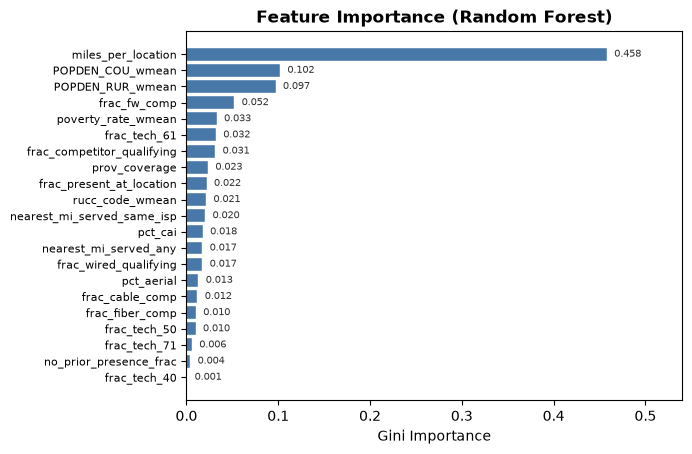

Saved: fig_feature_importance.pdf / .png


In [98]:
# ============================================================
# Figure 1: Feature Importance (Gini impurity-based)
# ============================================================
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
imp = imp.sort_values()

fig, ax = plt.subplots()
bars = ax.barh(imp.index, imp.values, color='#4878A8', edgecolor='white', linewidth=0.3)

# Annotate values
for bar, val in zip(bars, imp.values):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7, color='#333')

ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Random Forest)', weight='bold')
ax.set_xlim(0, imp.max() * 1.18)
ax.tick_params(axis='y', labelsize=8)

plt.savefig('fig_feature_importance.pdf')
plt.savefig('fig_feature_importance.png')
plt.show()
print('Saved: fig_feature_importance.pdf / .png')

In [24]:
df.to_csv('fp_enriched.csv',index=False)

In [203]:
print(type(X), X.shape)

<class 'pandas.core.frame.DataFrame'> (1, 21)


In [218]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

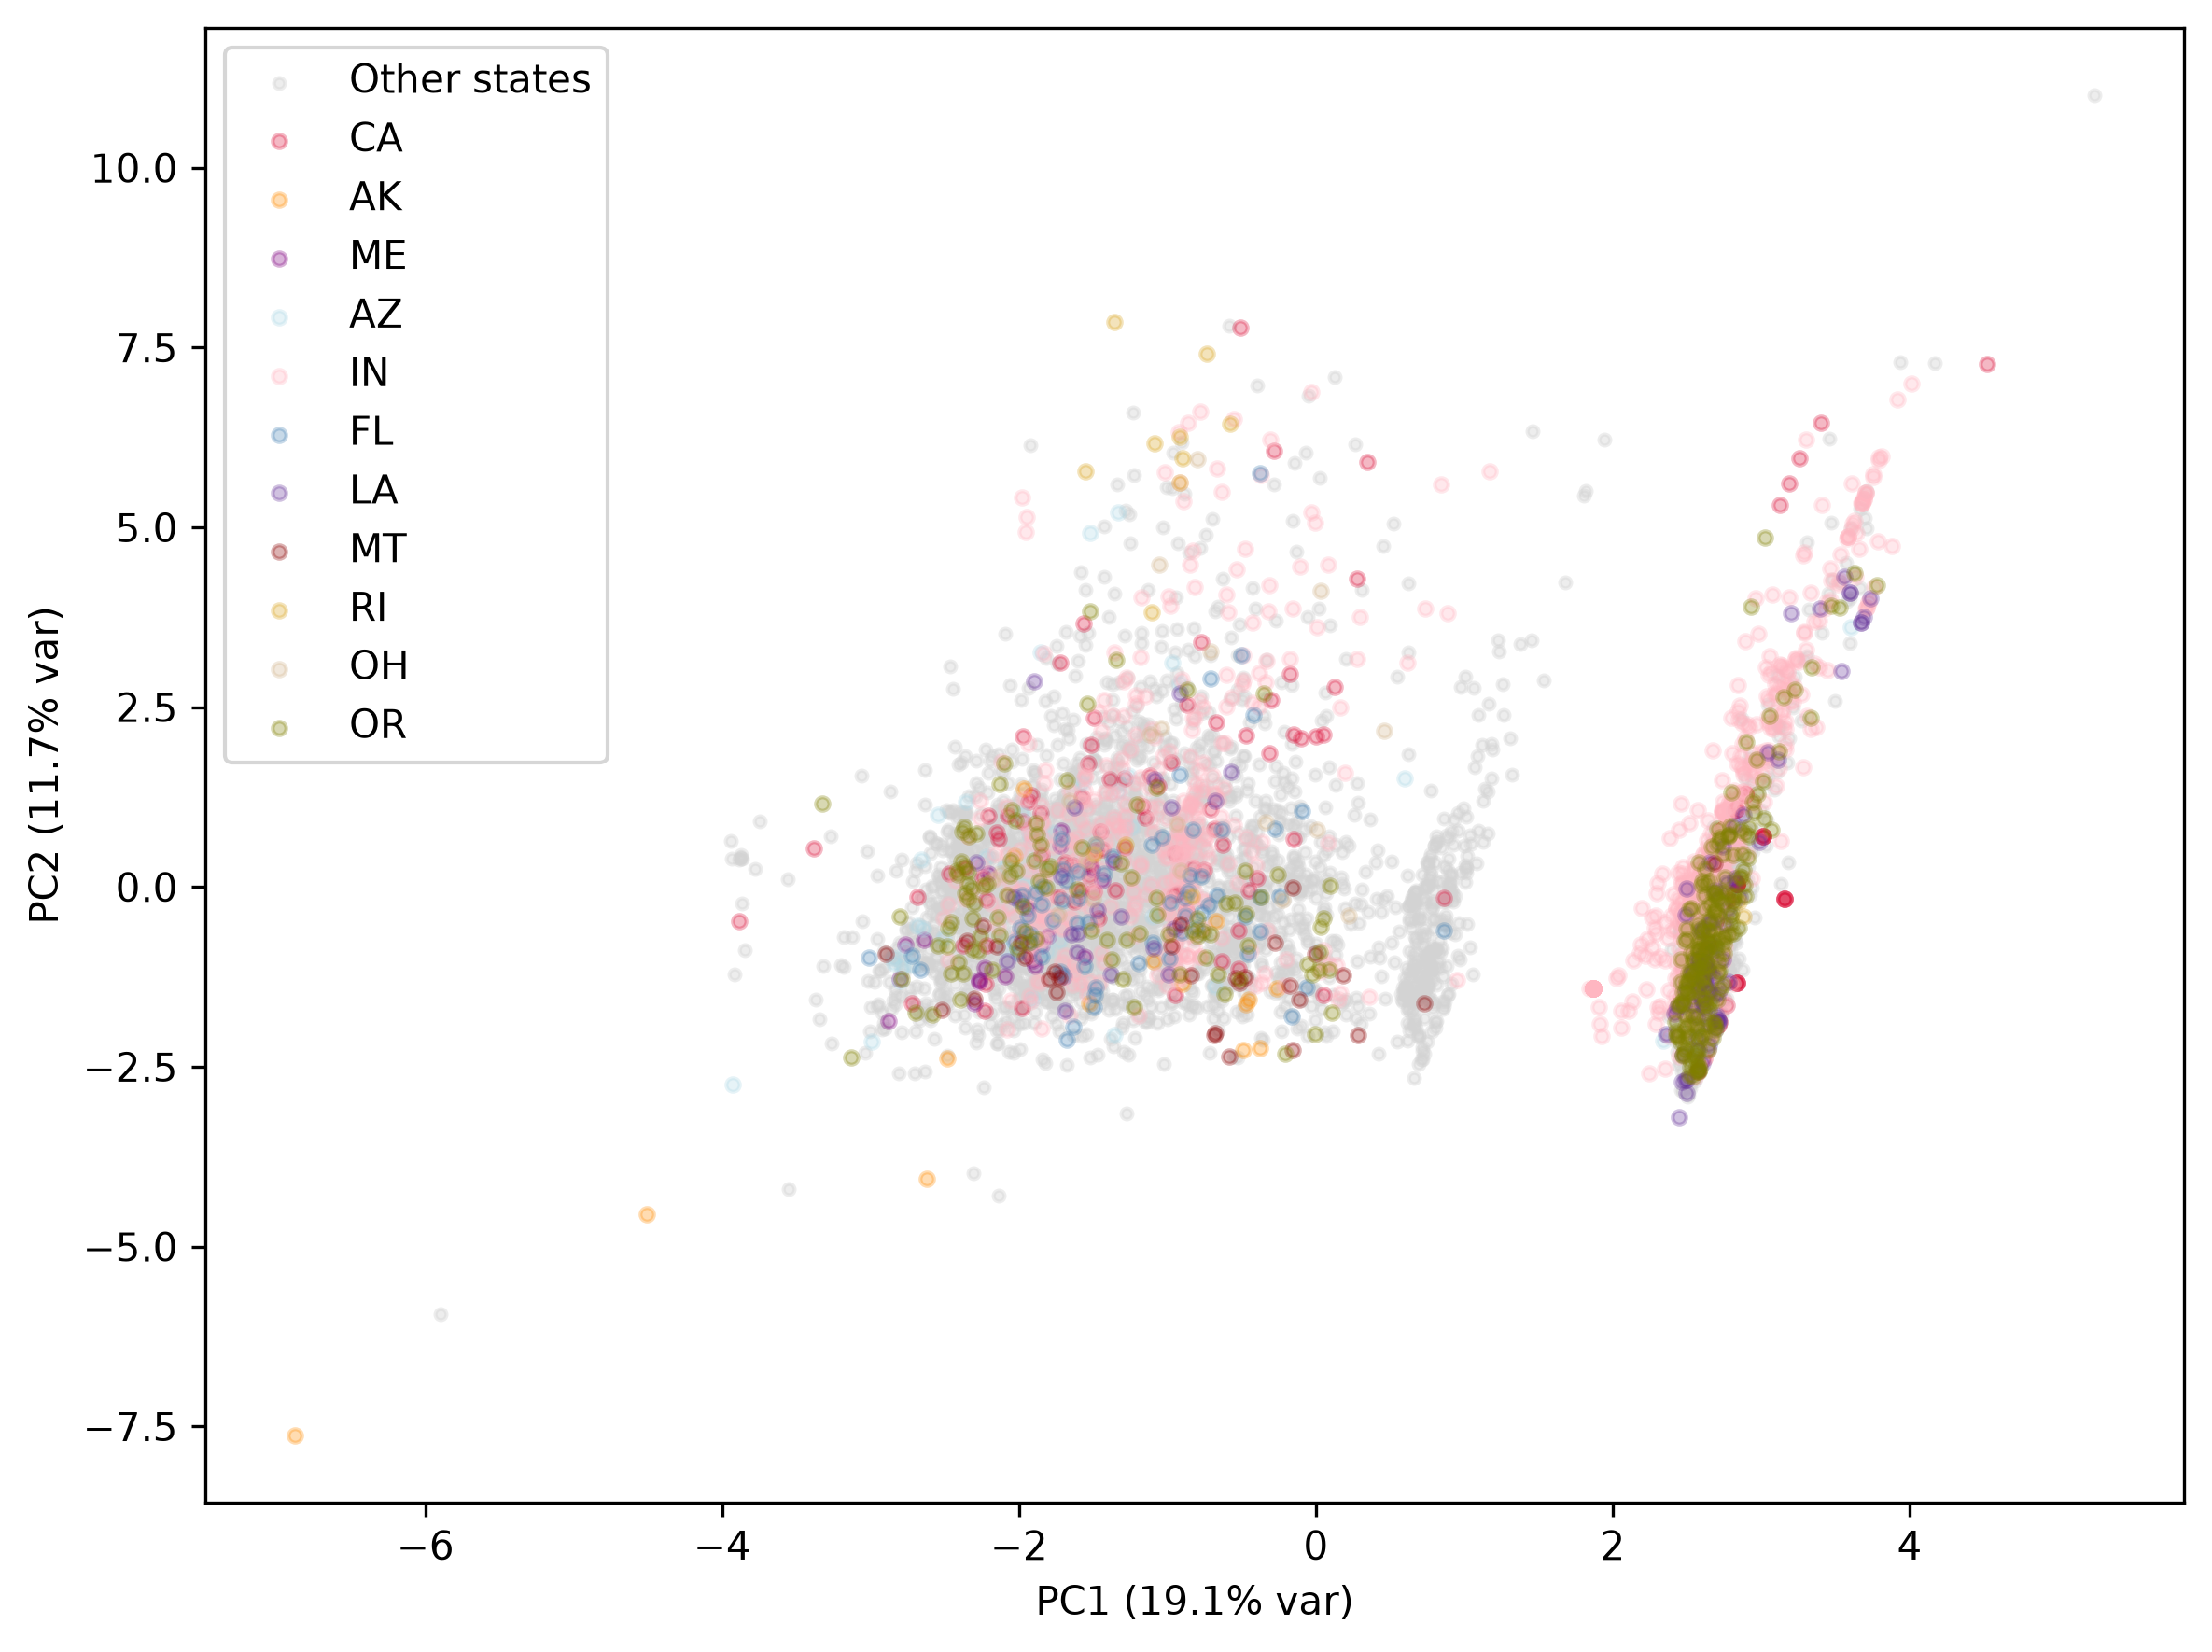

In [353]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df_trimmed[FEATURE_COLS].fillna(0)
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
highlight_states = {
'CA':'crimson',
'AK':'darkorange',
'ME':'purple',
'AZ':'lightblue',
'IN':'lightpink',
'FL':'steelblue',
'LA':'rebeccapurple',
'MT':'darkred',
'RI':'goldenrod',
'OH':'tan',
'OR':'olive'
}
other_mask = ~groups.isin(highlight_states)

ax.scatter(X_pca[other_mask, 0], X_pca[other_mask, 1],
           c='lightgray', s=8, alpha=0.4, label='Other states')
for state, color in highlight_states.items():
    mask = groups == state
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=12, alpha=0.3, label=state)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.legend()
plt.tight_layout()

In [ ]:
from scipy.spatial.distance import cdist

global_centroid = X_scaled.mean(axis=0, keepdims=True)
state_distances = {}
for state in groups.unique():
    mask = (groups == state).values
    state_centroid = X_scaled[mask].mean(axis=0, keepdims=True)
    state_distances[state] = cdist(state_centroid, global_centroid)[0, 0]

dist_df = pd.Series(state_distances).sort_values(ascending=False)
print(dist_df.head(10))

DC    20.369896
CT    10.440337
RI     5.926956
MA     5.708347
AK     5.443012
DE     4.937668
NJ     4.255417
KY     2.992989
ME     2.972923
MD     2.959025
dtype: float64


tech-share row sums — min 0.983, max 1.000


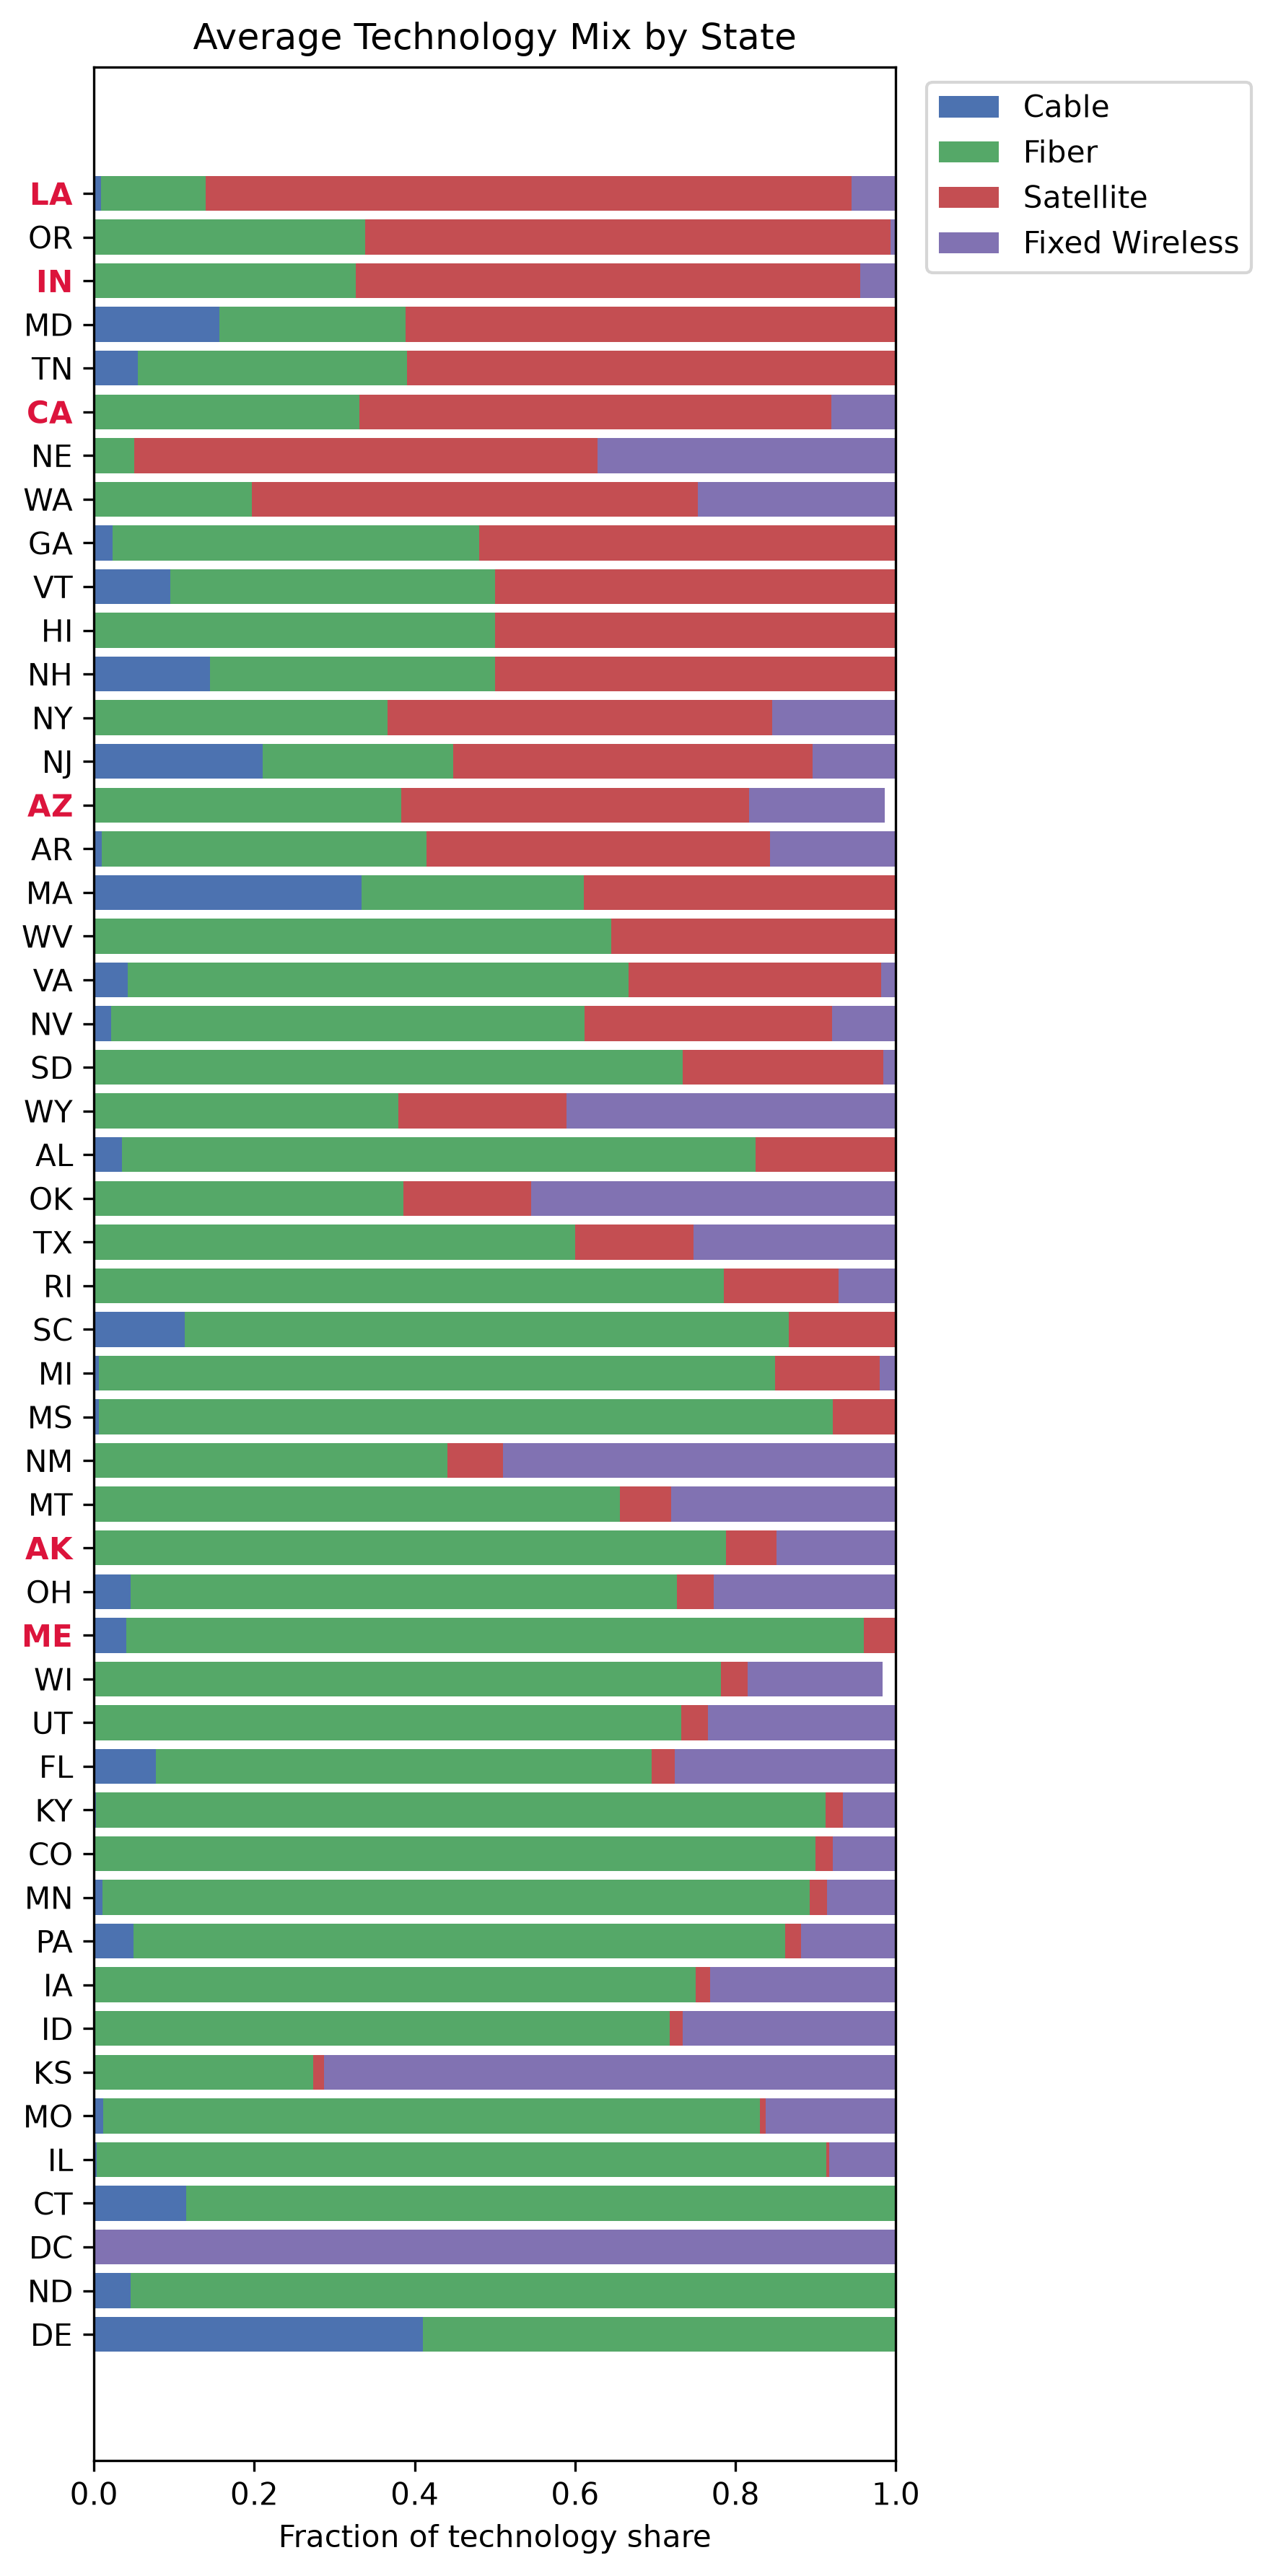

In [232]:
tech_cols = ['frac_tech_40', 'frac_tech_50', 'frac_tech_61', 'frac_tech_71']
tech_labels = {
    'frac_tech_40': 'Cable',
    'frac_tech_50': 'Fiber',
    'frac_tech_61': 'Satellite',
    'frac_tech_71': 'Fixed Wireless',
}

state_tech = df_trimmed.groupby(groups)[tech_cols].mean().rename(columns=tech_labels)

# check whether these four sum to ~1, or whether other codes (10, 72, etc.) are missing
row_sums = state_tech.sum(axis=1)
print(f"tech-share row sums — min {row_sums.min():.3f}, max {row_sums.max():.3f}")

state_tech_sorted = state_tech.sort_values('Satellite')

fig, ax = plt.subplots(figsize=(6, 12))
bottom = np.zeros(len(state_tech_sorted))
colors = {'Cable': '#4C72B0', 'Fiber': '#55A868', 'Satellite': '#C44E52', 'Fixed Wireless': '#8172B2'}

for tech in colors:
    ax.barh(state_tech_sorted.index, state_tech_sorted[tech],
             left=bottom, color=colors[tech], label=tech)
    bottom += state_tech_sorted[tech].values

highlight = {'IN', 'LA', 'CA', 'AK', 'ME', 'AZ'}
for lbl in ax.get_yticklabels():
    if lbl.get_text() in highlight:
        lbl.set_fontweight('bold')
        lbl.set_color('crimson')

ax.set_xlabel('Fraction of technology share')
ax.set_title('Average Technology Mix by State')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_tech_share_by_state.png', dpi=150, bbox_inches='tight')

In [231]:
print(state_tech_sorted['Satellite'].tail(10))

state_x
VT    0.500000
GA    0.519380
WA    0.555851
NE    0.577778
CA    0.588235
TN    0.609375
MD    0.611111
IN    0.628655
OR    0.654952
LA    0.805556
Name: Satellite, dtype: float64


In [ ]:
states_test_r2 = {}
states_cv_r2 = {}
for state, abbr in state_name_to_abbr.items():
    state_df = df_trimmed[df_trimmed['state_x'] == abbr]
    X = state_df[FEATURE_COLS].fillna(0)
    y = state_df['log_funding']

    if len(X) < 5:
        print(f'=== Dataset for {abbr} too small with n={len(X)}, skipping... ===')
        continue

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

    states_test_r2[abbr] = r2
    states_cv_r2[abbr] = cv_r2.mean()
    
    print(f'=== Final Model for {abbr} ==')
    print(f'Test R² (log):   {r2:.4f}')
    print(f'CV R² (log):     {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
    print(f'RMSE (real $):   {rmse:,.0f}')
    print(f'MAE (real $):    {mae:,.0f}\n')

In [243]:
pooled = pd.DataFrame.from_dict({"states": list(states_test_r2.keys()),
"test_r2": list(states_test_r2.values()),
"cv_r2": list(states_cv_r2.values()),
})

In [246]:
pooled = pooled.sort_values(by='test_r2', ascending=False)

In [367]:
pooled.to_csv('../state_rf.csv')

In [234]:
outlier_states = ['CA', 
        'AK', 
        'ME',
        'AZ',
        'IN',
        'FL',
        'LA',
        'MT',
        'RI',
        'OH',
        'UT',
        'KS',
        'ID'
]

X = df_trimmed[FEATURE_COLS].fillna(0)
y = df_trimmed['log_funding']
mask = ~groups.isin(outlier_states)
trimmed_r2 = r2_score(y[mask], y_pred_oof[mask])
print(f"Pooled OOF R² excluding CA, AK, ME: {trimmed_r2:.4f}")

Pooled OOF R² excluding CA, AK, ME: 0.6245


### Pooled OOF

In [335]:
df_try = df_trimmed[(df_trimmed['miles_per_location'] < 700)]

In [348]:
from sklearn.model_selection import cross_val_predict

groups = df_trimmed['state_x']
test_fold = balanced_group_folds(groups, n_splits=5)
ps = PredefinedSplit(test_fold=test_fold)
X = df_trimmed[FEATURE_COLS].fillna(0)
y = df_trimmed['log_funding']
y_pred_oof = cross_val_predict(rf, X, y, cv=ps, n_jobs=-1)  # or your GroupKFold
pooled_r2 = r2_score(y, y_pred_oof)
print(f"Pooled OOF R²: {pooled_r2:.4f}")

# per-state breakdown, same predictions
resid_df = pd.DataFrame({'state': groups, 'y': y, 'y_pred': y_pred_oof})
state_r2 = resid_df.groupby('state').apply(
    lambda g: r2_score(g['y'], g['y_pred']) if len(g) > 5 else np.nan
).sort_values()

Pooled OOF R²: 0.4366


In [349]:
fold_membership = pd.DataFrame({'state': groups.values, 'fold': test_fold})
for f in sorted(fold_membership['fold'].unique()):
    states_in_fold = sorted(fold_membership.loc[fold_membership['fold'] == f, 'state'].unique())
    n_rows = (fold_membership['fold'] == f).sum()
    print(f"Fold {f}: n={n_rows}, states={states_in_fold}")

Fold 0: n=1088, states=['IN', 'MD', 'NM', 'RI']
Fold 1: n=1084, states=['CO', 'DC', 'FL', 'LA', 'MI', 'NE', 'NY', 'SC', 'SD', 'VA', 'VT', 'WA']
Fold 2: n=1088, states=['AL', 'AZ', 'CA', 'CT', 'IA', 'MN', 'NJ', 'OH', 'OR', 'UT', 'WV']
Fold 3: n=1085, states=['AR', 'HI', 'ID', 'KY', 'MA', 'MO', 'MT', 'NH', 'TN', 'TX', 'WY']
Fold 4: n=1084, states=['AK', 'DE', 'GA', 'IL', 'KS', 'ME', 'MS', 'ND', 'NV', 'OK', 'PA', 'WI']


In [339]:
from sklearn.model_selection import LeaveOneGroupOut

# train on 45 states, predict on the 1 left out, 
# repeat for all 46 states, pool every held-out prediction into one set, 
# then compute a single R² over that pooled set
logo = LeaveOneGroupOut()
y_pred_loso = cross_val_predict(rf, X, y, cv=logo, groups=groups, n_jobs=-1)
pooled_r2_loso = r2_score(y, y_pred_loso)
print(pooled_r2_loso)

0.36661206171486516


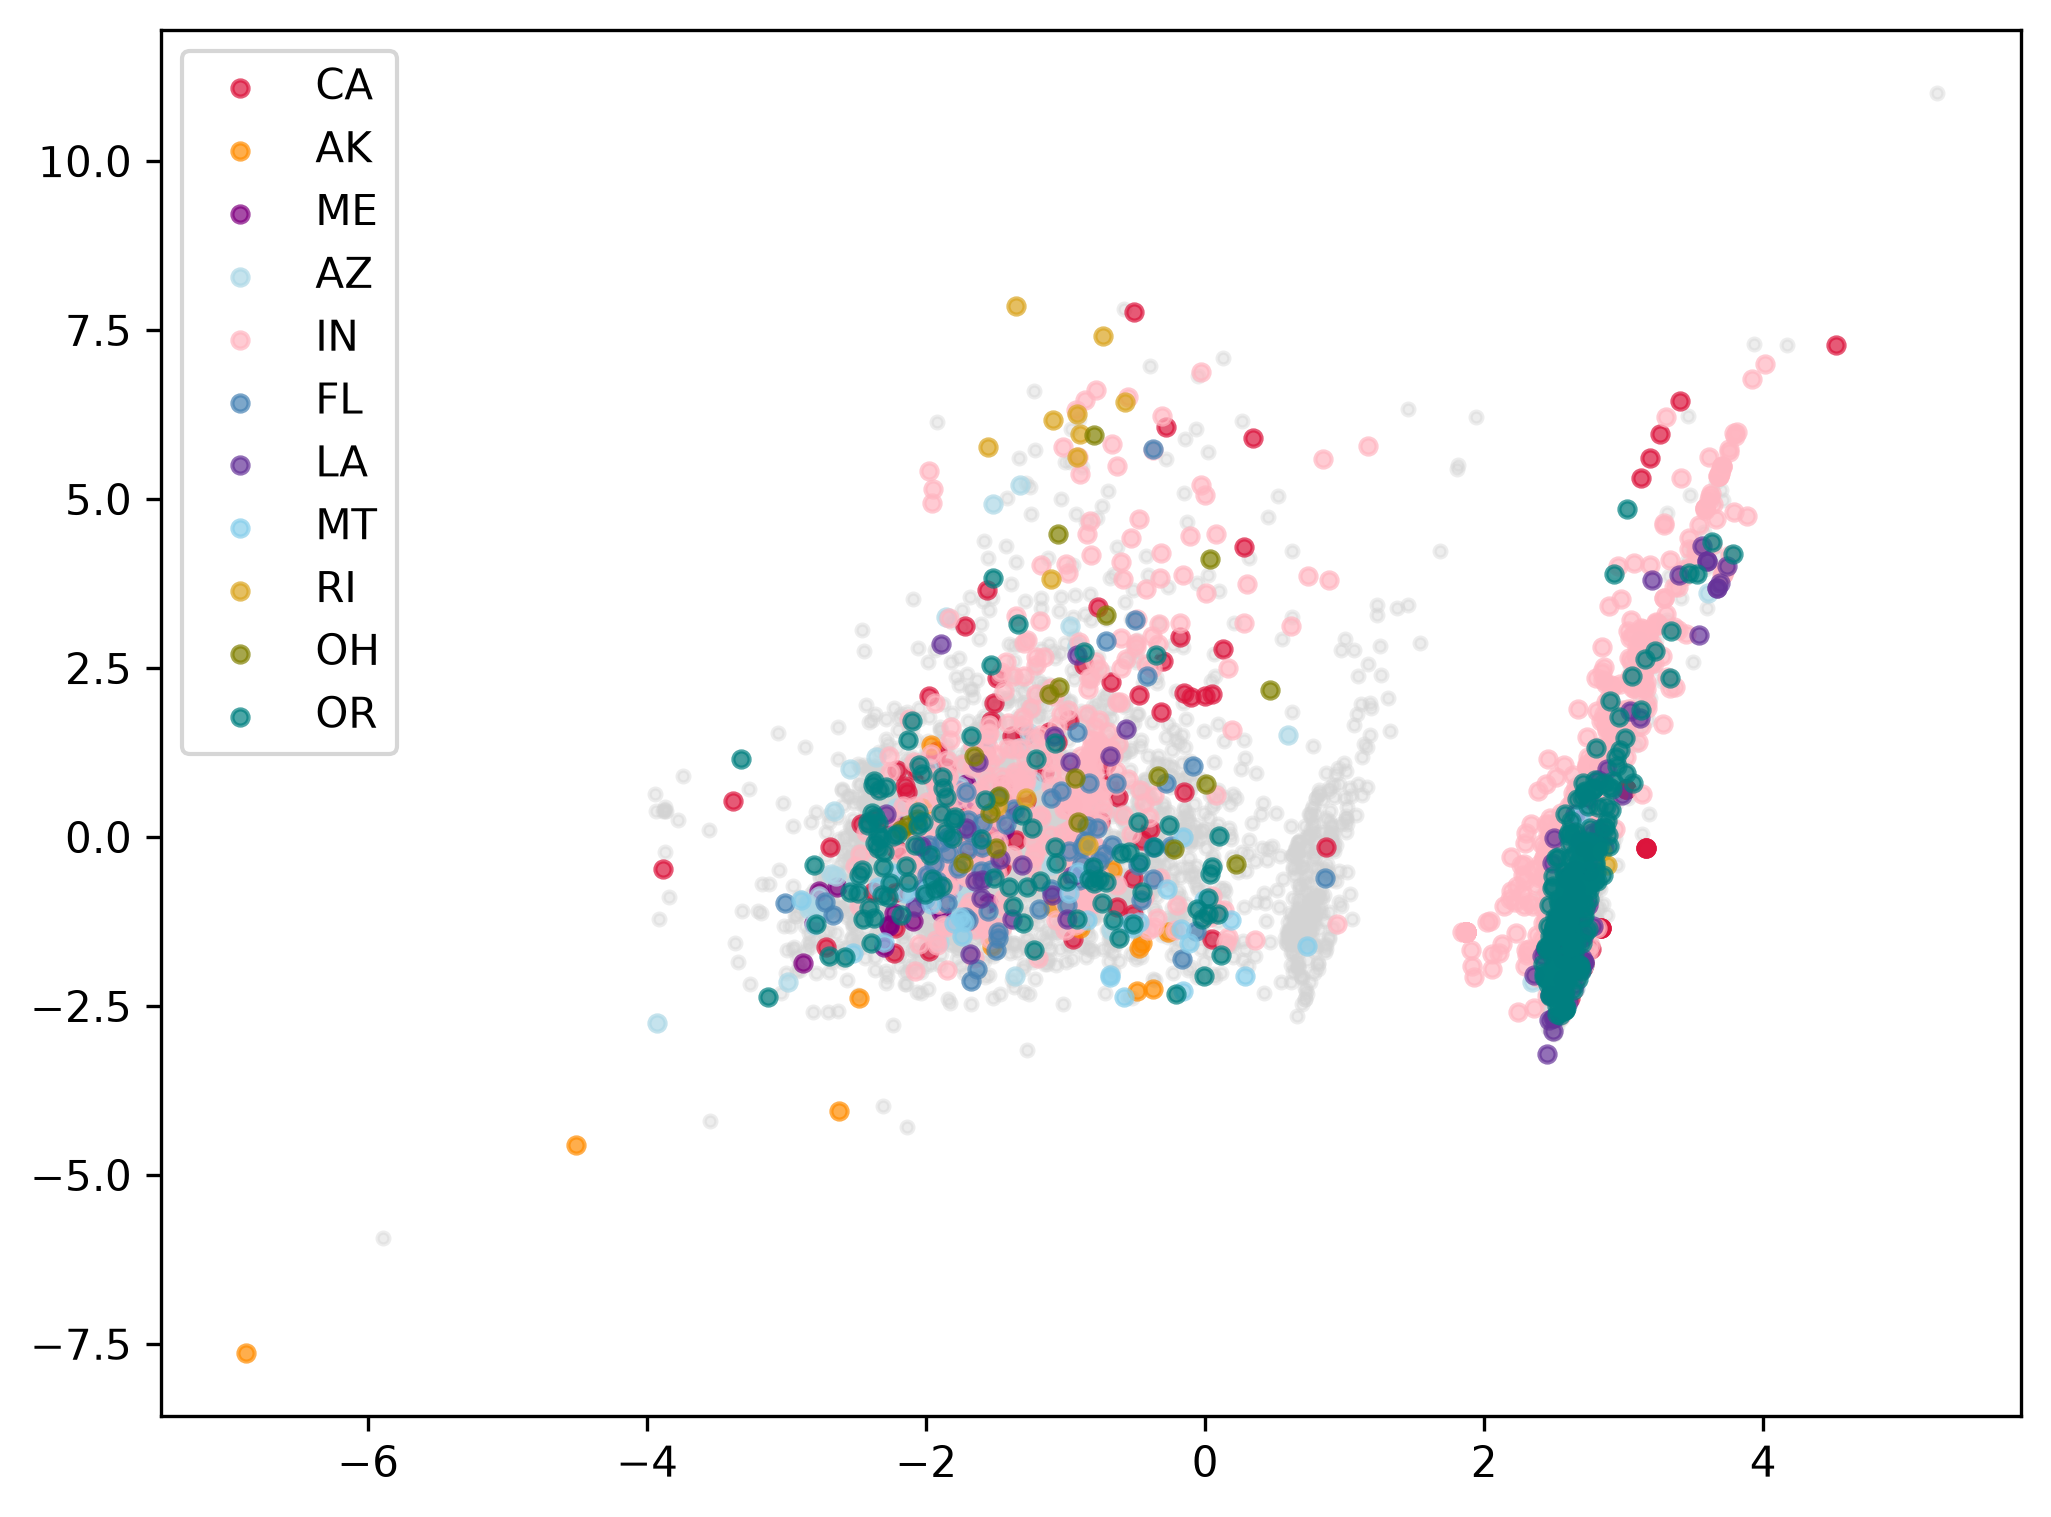

In [290]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[other_mask, 0], X_pca[other_mask, 1], c='lightgray', s=8, alpha=0.4)
for state, color in {**highlight_states, 'OR': 'teal'}.items():
    mask = groups == state
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=15, alpha=0.7, label=state)
ax.legend()

In [292]:
# isolate the right-side cluster via a PC1 threshold from the plot (looks like ~PC1 > 1.5)
cluster_mask = X_pca[:, 0] > 1.5

cluster_counts = pd.Series(groups[cluster_mask]).value_counts()
print("Cluster membership counts:")
print(cluster_counts.head(10))

# how far is each state's typical funding, within the cluster, from what
# the REST of the cluster (excluding that state) would predict?
cluster_y = y[cluster_mask]
cluster_groups = groups[cluster_mask]

for state in ['IN', 'OR', 'LA']:
    state_mask = cluster_groups == state
    state_mean = cluster_y[state_mask].mean()
    rest_mean = cluster_y[~state_mask].mean()
    print(f"{state}: n_in_cluster={state_mask.sum()}, own_mean={state_mean:.3f}, "
          f"rest_of_cluster_mean={rest_mean:.3f}, gap={state_mean - rest_mean:.3f}")

Cluster membership counts:
state_x
IN    644
OR    205
WA    152
GA    134
CA    119
LA     87
AR     65
NE     63
WV     48
AZ     30
Name: count, dtype: int64
IN: n_in_cluster=644, own_mean=7.373, rest_of_cluster_mean=7.232, gap=0.141
OR: n_in_cluster=205, own_mean=6.312, rest_of_cluster_mean=7.417, gap=-1.105
LA: n_in_cluster=87, own_mean=6.685, rest_of_cluster_mean=7.317, gap=-0.632


In [294]:
from sklearn.neighbors import NearestNeighbors

def mean_nn_distance_to_other_states(X_scaled, groups, k=5):
    results = {}
    for state in groups.unique():
        mask = (groups == state).values
        if mask.sum() < 3:
            continue
        nn = NearestNeighbors(n_neighbors=k).fit(X_scaled[~mask])
        dists, _ = nn.kneighbors(X_scaled[mask])
        results[state] = dists.mean()
    return pd.Series(results).sort_values(ascending=False)

nn_dist = mean_nn_distance_to_other_states(X_scaled, groups)
print(nn_dist.head(10))
print(nn_dist.corr(state_r2))

CT    5.205091
AK    3.467600
NJ    3.163402
MA    3.149140
RI    3.124845
OK    2.321694
AZ    1.968367
OH    1.935975
DE    1.916882
NM    1.902242
dtype: float64
-0.2053380832394435


In [314]:
import statsmodels.api as sm

state_level = df_trimmed.groupby(groups).agg(
    satellite_share=('technology', lambda x: (x == 61).mean()),
    popden=('POPDEN_COU_wmean', 'median'),
    poprur=('POPDEN_RUR_wmean', 'median'),
    rucc=('rucc_code_wmean', 'median'),
).dropna()

state_level = state_level[['satellite_share', 'popden', 'poprur','rucc']].astype('float64')

X_resid = sm.add_constant(state_level[['popden', 'poprur', 'rucc']])
resid_model = sm.OLS(state_level['satellite_share'], X_resid).fit()
state_level['satellite_residual'] = resid_model.resid
print(state_level.loc[['OR', 'LA', 'IN']])
print(state_level.sort_values('satellite_residual'))

         satellite_share      popden     poprur  rucc  satellite_residual
state_x                                                                  
OR              0.654952   51.372301  15.491651   3.0            0.366346
LA              0.805556   49.188453  27.109917   3.0            0.519779
IN              0.628655  100.215215  55.337151   4.0            0.381140
         satellite_share        popden      poprur      rucc  \
state_x                                                        
ND              0.000000     73.006432   10.219717  3.000000   
FL              0.028986    292.764325   46.044242  2.000000   
CO              0.021739     32.417015   14.475489  3.000000   
UT              0.027027     57.257358    9.964489  3.000000   
DE              0.000000    459.231412  111.316561  2.901076   
PA              0.019608    162.887597   78.248702  3.000000   
IL              0.004367     77.348311   37.019778  4.000000   
MN              0.021505     44.082441   26.995905  3.

In [263]:
state_pooled = resid_df.groupby('state').apply(
    lambda g: r2_score(g['y'], g['y_pred']) if len(g) > 5 else np.nan
).reset_index()
state_pooled.columns = ['state', 'pooled_r2']

In [398]:
subset = resid_df[resid_df['state'] == 'CA']
y_true = subset.y.values
y_pred = subset.y_pred.values

y_bar = np.mean(y_true)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_bar) ** 2)

print(ss_res, ss_tot)
print(1 - (ss_res / ss_tot))

1021.3193867145735 269.481881929833
-2.7899371171101666


In [388]:
state_pooled.sort_values(by='pooled_r2', ascending=True)

,state,pooled_r2
4,CA,-2.789937
21,ME,-1.762186
0,AK,-1.086251
3,AZ,-0.814720
38,RI,-0.645506
9,FL,-0.237984
15,IN,-0.215121
18,LA,-0.145429
10,GA,0.011018
47,WI,0.080504


In [266]:
state_pooled.sort_values(by='pooled_r2', ascending=True).to_csv("../pooled_r2.csv", index=False)

## SHAP Analysis

In [368]:
# Install if needed
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap
print(f'SHAP version: {shap.__version__}')

SHAP version: 0.51.0


In [369]:
# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (636, 22)


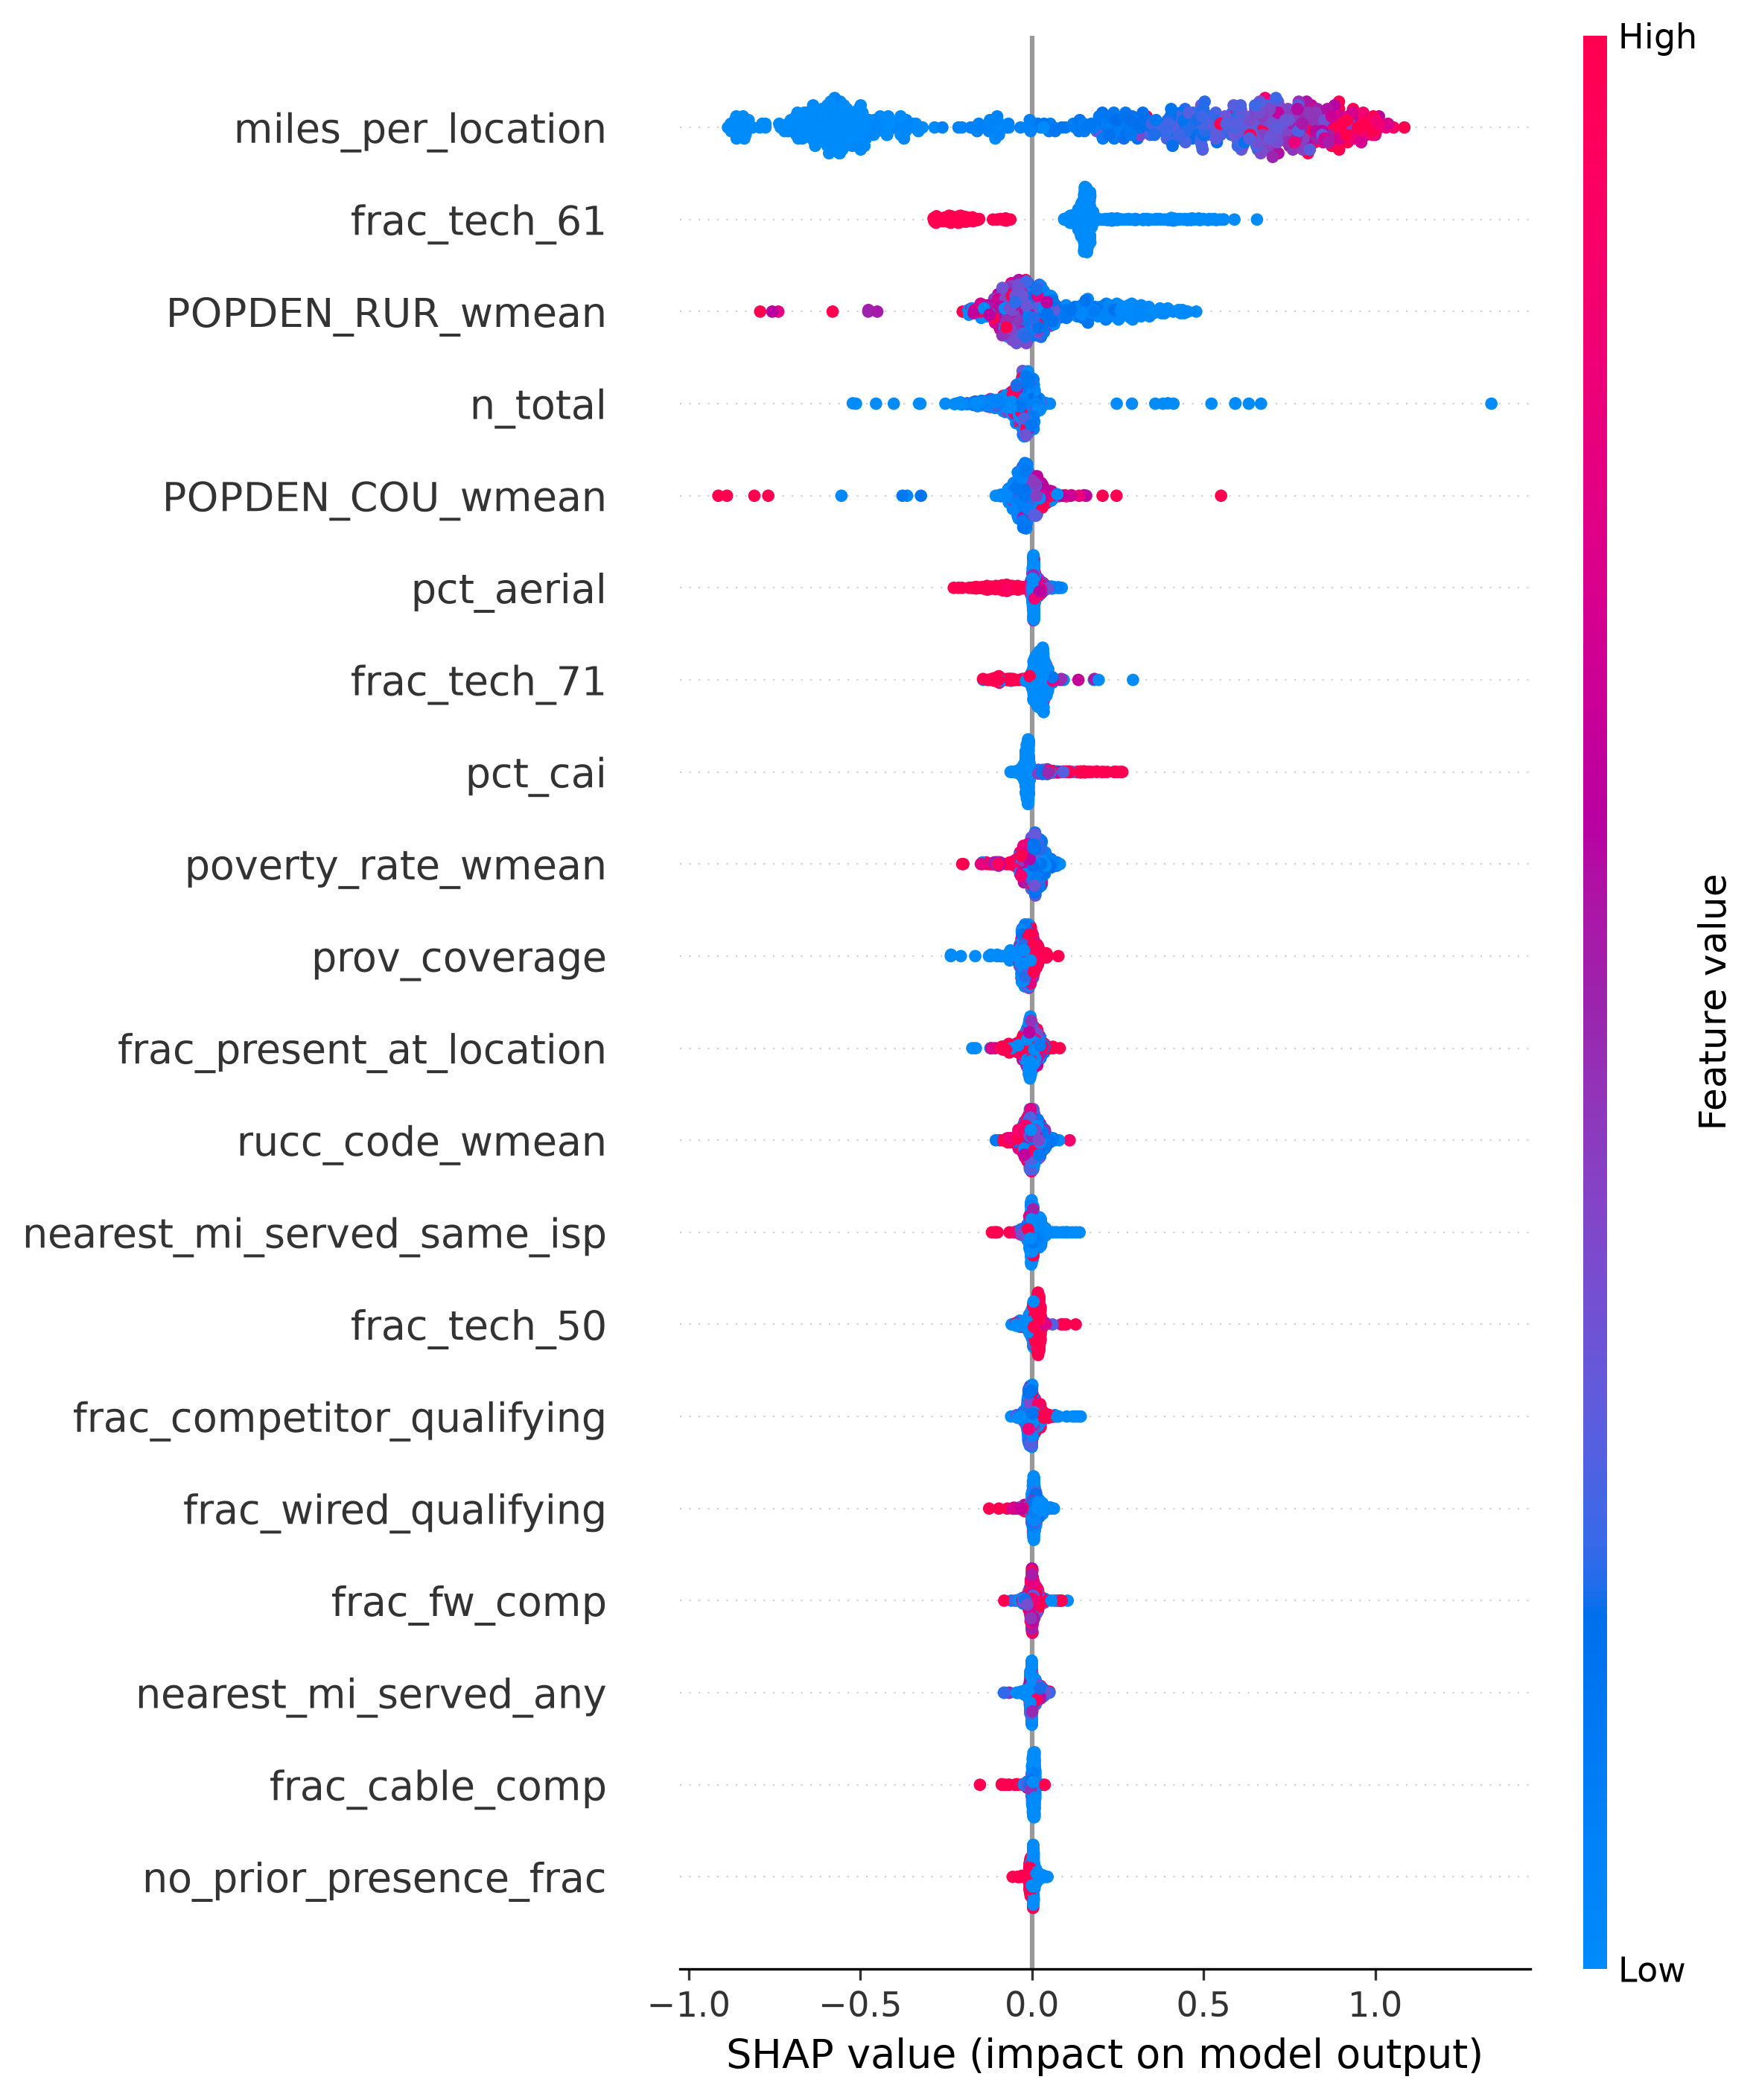

In [371]:
# SHAP summary plot — shows direction + magnitude of each feature's effect
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=True)

In [ ]:
# SHAP dependence plots for top 3 features
top3 = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3):
    shap.dependence_plot(feat, shap_values, X_test, feature_names=feature_cols, ax=axes[i], show=False)
plt.tight_layout()
plt.show()

In [ ]:
# SHAP waterfall for individual predictions
# Show highest and lowest funded projects
idx_high = y_test.idxmax()
idx_low = y_test.idxmin()

pos_high = list(X_test.index).index(idx_high)
pos_low = list(X_test.index).index(idx_low)

print('=== Highest Funded Project ===')
print(f'Actual: ${np.expm1(y_test.loc[idx_high]):,.0f}/location')
print(f'Predicted: ${np.expm1(y_pred[pos_high]):,.0f}/location')
shap.plots.waterfall(shap.Explanation(values=shap_values[pos_high], 
                                       base_values=explainer.expected_value,
                                       data=X_test.iloc[pos_high],
                                       feature_names=feature_cols), show=True)

print('\n=== Lowest Funded Project ===')
print(f'Actual: ${np.expm1(y_test.loc[idx_low]):,.0f}/location')
print(f'Predicted: ${np.expm1(y_pred[pos_low]):,.0f}/location')
shap.plots.waterfall(shap.Explanation(values=shap_values[pos_low],
                                       base_values=explainer.expected_value,
                                       data=X_test.iloc[pos_low],
                                       feature_names=feature_cols), show=True)